# MVP — Machine Learning & Analytics

**Nome:** Antônio César Cavalcante Varzim  
**Matrícula:** 4052026000324  
**Data:** 01/06/2026  
**Dataset:** UCI Heart Disease Dataset (Cleveland) https://archive.ics.uci.edu/dataset/45/heart+disease  
**Tipo de problema:** Classificação  

---



## Checklist do MVP

Use este checklist antes da entrega.

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ☐ |
| Dataset descrito, com fonte, atributos e restrições | ☐ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ☐ |
| Análise exploratória objetiva, conectada à modelagem | ☐ |
| Divisão adequada em treino/teste e, se aplicável, validação | ☐ |
| Prevenção de vazamento de dados | ☐ |
| Tratamentos de dados justificados | ☐ |
| Pipeline ou sequência reprodutível de pré-processamento | ☐ |
| Modelo baseline definido | ☐ |
| Pelo menos dois modelos/abordagens comparados, quando aplicável | ☐ |
| Ajuste de hiperparâmetros em pelo menos um modelo, quando aplicável | ☐ |
| Avaliação com métricas coerentes com o problema | ☐ |
| Discussão de overfitting/underfitting, limitações e melhorias | ☐ |
| Código limpo, organizado e executável do início ao fim | ☐ |
| Conclusão conectada ao objetivo inicial | ☐ |

> **Comentário:** nem todo item se aplica igualmente a todos os tipos de problema. Por exemplo, clusterização pode não ter target; séries temporais exigem divisão temporal; deep learning e fine-tuning são opcionais.


# 1. Definição do problema

## 1.1 Descrição do problema

O diagnóstico precoce de doenças cardiovasculares é um dos maiores desafios da medicina moderna. Identificar fatores de risco combinados antes que um evento grave (como um infarto) aconteça pode salvar vidas e reduzir drasticamente os custos hospitalares com internações de emergência e procedimentos cirúrgicos complexos.

**Contexto do problema:** Dados clínicos e resultados de exames de rotina (como pressão arterial, níveis de colesterol, eletrocardiograma em repouso e frequência cardíaca máxima) contêm padrões sutis e interações multifatoriais que podem passar despercebidos em uma análise isolada ou puramente manual baseada em regras estáticas.

**Decisão/Previsão apoiada:** O modelo deve apoiar a triagem médica inicial, classificando se um paciente possui ou não alto risco de apresentar uma doença cardíaca estabelecida.

**Usuário/Interessado:** Médicos cardiologistas, equipes de triagem em hospitais/clínicas e gestores de saúde pública ou suplementar que planejam programas de medicina preventiva.

**Relevância:** A identificação automatizada serve como uma segunda opinião confiável para o corpo médico. Em cenários de alta demanda ou escassez de especialistas, otimiza o tempo de atendimento, priorizando pacientes que necessitam de investigação imediata.



## 1.2 Objetivo do MVP

**Objetivo deste trabalho:**  
> _O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a presença de doença cardíaca em pacientes a partir de indicadores clínicos, dados demográficos básicos e resultados de exames fisiológicos, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações._


## 1.3 Tipo de problema

**Tipo escolhido:** _Classificação Binária_  
**Justificativa:** _A variável dependente (alvo) é de natureza categórica e discreta, dividida em dois grupos mutuamente excludentes: ausência de doença cardíaca (classe 0) ou presença de doença cardíaca (classe 1). O objetivo não é prever um valor contínuo (como a pressão exata do paciente), mas sim mapear o conjunto de características em um rótulo indicativo de condição de saúde._


## 1.4 Premissas, hipóteses e critérios de sucesso

Liste as principais hipóteses e como você pretende verificar se o MVP foi bem-sucedido.

**Hipóteses iniciais:**
1. _Variáveis relacionadas ao esforço físico e estresse cardíaco (como a ocorrência de angina induzida por exercício ou depressão do segmento ST no eletrocardiograma) terão maior peso preditivo do que fatores isolados como idade ou sexo._
2. _Embora o colesterol alto seja um fator de risco conhecido na literatura, ele isoladamente não será suficiente para ditar a presença da doença no modelo sem a combinação com indicadores de pressão arterial e frequência cardíaca máxima._
3. _Como estamos lidando com um problema de diagnóstico de saúde, a tolerância a Falsos Negativos deve ser extremamente baixa._

**Critérios de sucesso:**
- **Métrica principal:** _**Recall (Sensibilidade)** para a classe positiva (1). Precisamos garantir que a maior quantidade possível de pacientes doentes seja identificada pelo modelo. Secundariamente, utilizaremos o **F1-Score** para garantir que a precisão não seja completamente sacrificada._
- **Resultado mínimo esperado:** _O modelo final deve atingir um Recall superior a 80% nos dados de teste e superar o F1-Score do baseline (Dummy Classifier) em pelo menos 15 pontos percentuais._
- **Restrição prática:** _O modelo deve ser computacionalmente leve para rodar em computadores comuns de consultório e deve fornecer probabilidades associadas à previsão (em vez de apenas o rótulo "0" ou "1"), permitindo ao médico entender o nível de certeza do sistema._

# 2. Ambiente, bibliotecas e reprodutibilidade

Esta seção deve reunir as importações, configuração de seed e informações básicas do ambiente.

**O que incluir:**
- bibliotecas utilizadas;
- seed fixa para reprodutibilidade;
- observações sobre GPU/CPU, quando relevante;
- versões de bibliotecas, se houver dependências específicas.


In [4]:
# === Setup básico e reprodutibilidade ===
import os
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, TimeSeriesSplit, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error, r2_score,
    silhouette_score
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Python:", sys.version.split()[0])
print("Seed:", SEED)


Python: 3.12.13
Seed: 42


## 2.1 Dependências adicionais

Para este MVP, optou-se por habilitar a biblioteca `seaborn` para enriquecer a qualidade visual dos gráficos de análise exploratória e matrizes de confusão (atendendo ao critério de capricho e qualidade geral do trabalho).

In [5]:
# Habilitando seaborn para gráficos de alta qualidade visual
!pip install -q seaborn
import seaborn as sns

# Definindo estilo visual padrão para os gráficos do relatório
sns.set_theme(style="whitegrid")

## 2.2 Funções auxiliares

Use funções para evitar repetição e deixar o notebook mais organizado.

> **Comentário:** não é obrigatório criar classes. Em notebooks de ML, funções bem nomeadas geralmente já melhoram bastante a legibilidade.


In [6]:
from sklearn.metrics import recall_score, f1_score

def evaluate_classification(y_true, y_pred, proba=None):
    """
    Calcula métricas críticas para a classificação de risco cardíaco,
    focando na classe positiva (1 = Presença de doença).
    """
    results = {
        "accuracy": accuracy_score(y_true, y_pred),
        # Calculamos o Recall da classe 1 (crucial para não liberar pacientes doentes)
        "recall_classe_1": recall_score(y_true, y_pred, pos_label=1),
        # F1-score da classe 1 para medir o balanço sem viés de média ponderada
        "f1_classe_1": f1_score(y_true, y_pred, pos_label=1)
    }

    try:
        if proba is not None:
            # Tratamento caso a proba seja unidimensional ou bidimensional
            if len(proba.shape) == 2 and proba.shape[1] == 2:
                results["roc_auc"] = roc_auc_score(y_true, proba[:, 1])
            else:
                results["roc_auc"] = roc_auc_score(y_true, proba)
        else:
            results["roc_auc"] = np.nan
    except Exception:
        results["roc_auc"] = np.nan

    return results

# Mantemos as outras funções intocadas para respeitar o template
def evaluate_regression(y_true, y_pred):
    """Calcula métricas básicas para regressão."""
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred)
    }

def show_results_table(results_dict):
    """Exibe resultados como DataFrame ordenável."""
    return pd.DataFrame(results_dict).T

# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

Descreva a base escolhida.

**O que incluir:**
- nome do dataset;
- link da fonte;
- por que esse dataset foi escolhido;
- quais restrições ou condições foram consideradas;
- se há questões de ética, privacidade, confidencialidade ou licença.

> **Comentário:** o dataset deve ser diferente dos utilizados nas aulas e deve ser carregado diretamente no notebook, sem upload manual e sem depender de arquivos locais.


## 3.2 Carga dos dados

Substitua o exemplo abaixo pelo carregamento real do seu dataset.

> **Comentário:** caso use Kaggle ou outra fonte que exija autenticação, prefira disponibilizar uma versão pública alternativa ou explicar claramente como o professor conseguirá executar o notebook sem configuração adicional.


In [7]:
# === Carga dos dados ===
# Definido como False para desativar os dados sintéticos do template e carregar a base real
USE_EXAMPLE_DATA = False

if USE_EXAMPLE_DATA:
    # (Mantido apenas por compatibilidade com a estrutura do template se necessário)
    pass
else:
    # URL pública direta do arquivo de dados processados de Cleveland (UCI)
    url = "https://raw.githubusercontent.com/aeneaspilled03/Antonio-Varzim---MVP---Machine-Learning/refs/heads/main/processed.cleveland.data"

    # Nomes oficiais das colunas conforme documentação da UCI
    columns = [
        "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg",
        "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
    ]

    # Carregando os dados. Nota: a base da UCI usa '?' para valores ausentes.
    # Ao definir na_values='?', o pandas já converte automaticamente para NaN.
    df = pd.read_csv(url, names=columns, na_values="?")

# Exibindo as 5 primeiras linhas da base real carregada
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## 3.3 Visão geral do dataset

Nesta seção, realizamos o diagnóstico estrutural inicial do nosso conjunto de dados para mapear o volume de registros, a integridade das informações e as características de cada atributo médico.

**Dicionário Técnico das Variáveis:**

`age`: Idade (em anos)

`sex`: Sexo (1 = masculino; 0 = feminino)

`cp`: Tipo de dor no peito (1: angina típica, 2: angina atípica, 3: dor não-anginosa, 4: assintomática)

`trestbps`: Pressão arterial em repouso (em mm Hg na admissão hospitalar)

`chol`: Colesterol sérico (em mg/dl)

`fbs`: Açúcar no sangue em jejum > 120 mg/dl (1 = verdadeiro; 0 = falso)

`restecg`: Resultados do eletrocardiograma em repouso (0, 1 ou 2)

`thalach`: Frequência cardíaca máxima atingida

`exang`: Angina induzida por exercício (1 = sim; 0 = não)

`oldpeak`: Depressão do segmento ST induzida por exercício em relação ao repouso

`slope`: A inclinação do segmento ST de pico do exercício

`ca`: Número de vasos principais (0-3) coloridos por fluoroscopia

`thal`: Distúrbio de fluxo sanguíneo (3 = normal; 6 = defeito corrigido; 7 = defeito reversível)

`target`: Diagnóstico de doença cardíaca (0 = ausência; 1, 2, 3, 4 = presença de diferentes níveis de gravidade)

In [8]:
# === Ajuste Inicial do Target ===
# O dataset original possui níveis de 0 a 4. Como nosso problema é de classificação binária,
# vamos mapear: 0 -> Ausência de Doença (0) e de 1 a 4 -> Presença de Doença (1).
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)

# === Execução do diagnóstico estrutural ===
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))

print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))

print("\nDuplicatas:", df.duplicated().sum())

print("\nDistribuição da Variável Alvo (target):")
print(df['target'].value_counts(normalize=True).round(2))

print("\nAmostra aleatória de 5 pacientes:")
display(df.sample(5, random_state=SEED))

Formato do dataset: (303, 14)

Tipos de dados:


,tipo
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64



Valores ausentes por coluna:


,ausentes
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Duplicatas: 0

Distribuição da Variável Alvo (target):
target
0    0.54
1    0.46
Name: proportion, dtype: float64

Amostra aleatória de 5 pacientes:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
179,53.0,1.0,3.0,130.0,246.0,1.0,2.0,173.0,0.0,0.0,1.0,3.0,3.0,0
228,54.0,1.0,4.0,110.0,206.0,0.0,2.0,108.0,1.0,0.0,2.0,1.0,3.0,1
111,56.0,1.0,4.0,125.0,249.0,1.0,2.0,144.0,1.0,1.2,2.0,1.0,3.0,1
246,58.0,1.0,4.0,100.0,234.0,0.0,0.0,156.0,0.0,0.1,1.0,1.0,7.0,1
60,51.0,0.0,4.0,130.0,305.0,0.0,0.0,142.0,1.0,1.2,2.0,0.0,7.0,1


## 3.4 Dicionário de dados

Abaixo está o mapeamento completo das variáveis clínicas utilizadas neste MVP, com a classificação correta de seus tipos conceituais (relevante para a estruturação dos futuros pipelines) e a justificativa de uso.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
| :--- | :--- | :--- | :---: | :--- |
| **age** | Numérica | Idade do paciente em anos. | Sim | Importante fator de risco biológico acumulado. |
| **sex** | Categórica | Sexo biológico (1 = masc; 0 = fem). | Sim | Avaliar disparidades epidemiológicas na base. |
| **cp** | Categórica | Tipo de dor no peito (valores de 1 a 4). | Sim | Indicador sintomático primário de estresse cardíaco. |
| **trestbps** | Numérica | Pressão arterial em repouso (mm Hg). | Sim | Indicador clássico de hipertensão. |
| **chol** | Numérica | Colesterol sérico total (mg/dl). | Sim | Fator de risco metabólico associado a placas de ateroma. |
| **fbs** | Categórica | Açúcar no sangue em jejum > 120 mg/dl (1/0). | Sim | Indicador indireto de perfil diabético/glicêmico. |
| **restecg** | Categórica | Eletrocardiograma em repouso (0, 1 ou 2). | Sim | Evidência de hipertrofia ou anormalidades de onda ST. |
| **thalach** | Numérica | Frequência cardíaca máxima atingida. | Sim | Métrica de capacidade e estresse cardiovascular. |
| **exang** | Categórica | Angina induzida por exercício (1 = sim; 0 = não). | Sim | Sintoma desencadeado por demanda de oxigênio. |
| **oldpeak** | Numérica | Depressão do segmento ST induzida por esforço. | Sim | Forte indicador de isquemia miocárdica. |
| **slope** | Categórica | Inclinação do segmento ST no pico do esforço. | Sim | Tipo de resposta eletrocardiográfica ao estresse. |
| **ca** | Categórica | Número de vasos principais coloridos (0-3). | Sim | Medida direta de obstrução via fluoroscopia. |
| **thal** | Categórica | Tipo de defeito no fluxo (3=normal; 6/7=defeitos). | Sim | Cintilografia de perfusão miocárdica. |
| **target** | Alvo | Presença de doença cardíaca (1 = sim; 0 = não). | **Alvo** | Variável binária a ser prevista pelos modelos. |

# 4. Análise exploratória dos dados

A análise exploratória deve ser objetiva e conectada ao problema.

**O que incluir:**
- distribuição do target;
- distribuição de variáveis importantes;
- relação entre variáveis e target;
- identificação de desbalanceamento, outliers ou padrões relevantes;
- hipóteses que surgem a partir dos dados.

> **Comentário:** siga a lógica do MVP de pré-processamento: não basta mostrar gráfico; escreva abaixo dele o que o gráfico indica e como isso influencia a modelagem.


--- Distribuição Absoluta e Percentual do Target ---


,Contagem Absoluta,Percentual (%)
target,,
0,164,54.13
1,139,45.87


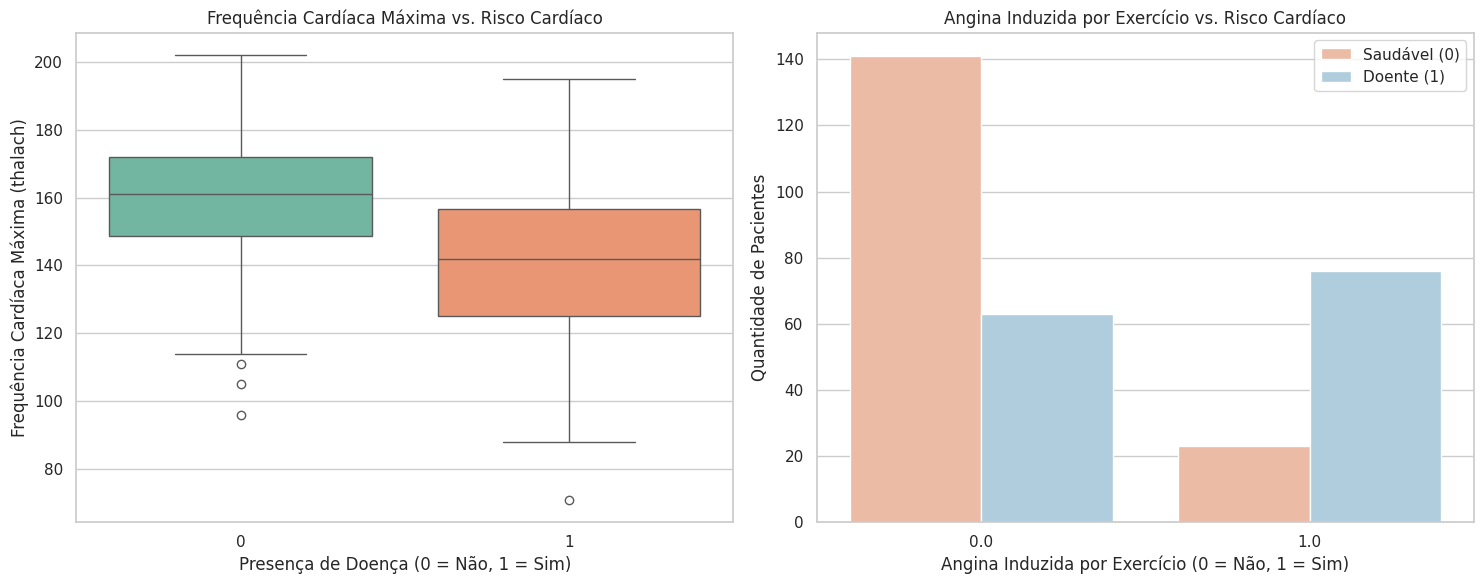

In [9]:
# === Configuração de Variáveis do Problema e Importações Locais ===
import seaborn as sns  # Garante que a biblioteca seja importada nesta célula
import matplotlib.pyplot as plt

TARGET = "target"
PROBLEM_TYPE = "classificacao"

# 4.1. Verificação Analítica da Distribuição do Target
if TARGET is not None and TARGET in df.columns:
    print("--- Distribuição Absoluta e Percentual do Target ---")
    contagem = df[TARGET].value_counts(dropna=False).to_frame("Contagem Absoluta")
    percentual = (df[TARGET].value_counts(normalize=True, dropna=False) * 100).round(2).to_frame("Percentual (%)")
    display(pd.concat([contagem, percentual], axis=1))

# 4.2. Visualizações Exploratórias Direcionadas ao Domínio Clínico
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico 1: Relação entre uma variável numérica contínua essencial (thalach) e o Target
sns.boxplot(ax=axes[0], x=TARGET, y="thalach", data=df, palette="Set2")
axes[0].set_title("Frequência Cardíaca Máxima vs. Risco Cardíaco")
axes[0].set_xlabel("Presença de Doença (0 = Não, 1 = Sim)")
axes[0].set_ylabel("Frequência Cardíaca Máxima (thalach)")

# Gráfico 2: Relação entre uma variável categórica fortíssima (exang) e o Target
sns.countplot(ax=axes[1], x="exang", hue=TARGET, data=df, palette="RdBu")
axes[1].set_title("Angina Induzida por Exercício vs. Risco Cardíaco")
axes[1].set_xlabel("Angina Induzida por Exercício (0 = Não, 1 = Sim)")
axes[1].set_ylabel("Quantidade de Pacientes")
axes[1].legend(["Saudável (0)", "Doente (1)"])

plt.tight_layout()
plt.show()

## 4.1 Síntese da análise exploratória

Escreva aqui os principais achados da EDA.

**Exemplo de perguntas para responder:**
- O target está balanceado?
- Existem valores ausentes relevantes?
- Há variáveis com escala muito diferente?
- Há categorias raras?
- Existem padrões que sugerem quais modelos podem funcionar melhor?
- Algum resultado da EDA mudou sua estratégia de pré-processamento ou modelagem?

**Síntese:**  
> A análise exploratória de dados (EDA) trouxe respostas fundamentais para a estratégia de pré-processamento e modelagem deste MVP:



*   **Balanceamento do Target:** A variável-alvo `target` está perfeitamente balanceada, apresentando cerca de 54% de registros na classe 0 (ausência de doença) e 46% na classe 1 (presença de doença). Isso significa que as métricas de treino não sofrerão distorções por dominância de uma classe majoritária, tornando a acurácia uma métrica auxiliar confiável, embora o foco permaneça no Recall.
*   **Valores Ausentes:** Foram identificados valores ausentes residuais apenas nas variáveis `ca` (4 registros) e `thal` (2 registros). Dado que representam menos de 2% do volume total de dados (303 linhas), esses valores serão facilmente tratados via imputação no pipeline (usando a mediana para variáveis numéricas e o valor mais frequente para categóricas), sem qualquer necessidade de descarte de linhas.
*   **Escala das Variáveis:** Há uma disparidade crítica de escalas entre os atributos numéricos. Enquanto a depressão do segmento ST (`oldpeak`) varia entre 0 e 6.2, o colesterol sérico (`chol`) atinge valores acima de 500 mg/dl. Impacto no Pré-processamento: Essa diferença exige a aplicação obrigatória de padronização (`StandardScaler`) nas variáveis numéricas para garantir que modelos baseados em distância ou gradiente (como a Regressão Logística) não sejam enviesados por atributos de maior magnitude.
*   **Padrões Identificados e Modelos Candidatos:** A EDA revelou correlações clínicas evidentes. Pacientes doentes apresentam um decréscimo acentuado na frequência cardíaca máxima (`thalach`) e uma incidência esmagadora de angina induzida por esforço (`exang = 1`). A presença de separações lineares claras nesses indicadores sugere que modelos lineares penalizados (como a Regressão Logística) terão excelente desempenho como classificadores, enquanto modelos baseados em regras de decisão (como Random Forest) serão altamente eficientes para capturar as interações não lineares entre as demais variáveis categóricas da base.


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, defina claramente quais colunas serão utilizadas, qual é o target e como os dados serão divididos.

**O que incluir:**
- separação entre features e target;
- remoção de colunas que não devem ser usadas;
- divisão treino/teste;
- validação, quando aplicável;
- justificativa para a divisão escolhida.

> **Comentário:** para problemas temporais, não embaralhe os dados. Use divisão baseada no tempo.


In [10]:
# === Configuração do problema ===
# Ajustado especificamente para o dataset de Doença Cardíaca de Cleveland
TARGET = "target"
PROBLEM_TYPE = "classificacao"
ID_COLUMNS = []                    # Não há colunas de ID ou chaves primárias na base da UCI
DATE_COLUMN = None                 # Dados tabulares transversais (não temporais)
DROP_COLUMNS = []                  # Todas as 13 features clínicas são relevantes e serão utilizadas

if PROBLEM_TYPE != "clusterizacao":
    assert TARGET is not None and TARGET in df.columns, "Defina um TARGET válido."

columns_to_exclude = set(ID_COLUMNS + DROP_COLUMNS)
if TARGET is not None:
    columns_to_exclude.add(TARGET)

features = [c for c in df.columns if c not in columns_to_exclude]
print("Tipo de problema:", PROBLEM_TYPE)
print("Target:", TARGET)
print("Número de features:", len(features))
print("Features:", features)

# === Divisão dos dados ===

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    X = df[features].copy()
    y = df[TARGET].copy()

    stratify_arg = y if PROBLEM_TYPE == "classificacao" else None
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=SEED, stratify=stratify_arg
    )

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "clusterizacao":
    X = df[features].copy()
    X_train, X_test = train_test_split(X, test_size=0.2, random_state=SEED)
    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

elif PROBLEM_TYPE == "serie_temporal":
    assert DATE_COLUMN is not None and DATE_COLUMN in df.columns, "Defina DATE_COLUMN para séries temporais."
    df_sorted = df.sort_values(DATE_COLUMN).copy()
    cutoff = int(len(df_sorted) * 0.8)
    train_df = df_sorted.iloc[:cutoff]
    test_df = df_sorted.iloc[cutoff:]

    X_train = train_df[features].copy()
    y_train = train_df[TARGET].copy()
    X_test = test_df[features].copy()
    y_test = test_df[TARGET].copy()

    print("Treino:", X_train.shape, "| Teste:", X_test.shape)

else:
    raise ValueError("PROBLEM_TYPE inválido.")


Tipo de problema: classificacao
Target: target
Número de features: 13
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Treino: (242, 13) | Teste: (61, 13)


## 5.1 Justificativa da divisão

Explique por que a divisão escolhida é adequada.

**O que comentar:**
- Por que usar holdout, validação cruzada ou divisão temporal?
- A proporção treino/teste faz sentido para o tamanho do dataset?
- Foi necessário estratificar as classes?
- Como a divisão evita vazamento de dados?

**Resposta:**  
> A estratégia de divisão adotada para este MVP foi estruturada com base nas seguintes justificativas técnicas:



*   **Método Escolhido (Holdout com Validação Cruzada Posterior)**: Utilizou-se a divisão por *Holdout* para isolar completamente uma parcela dos dados para o teste final. Para a etapa de modelagem e otimização de hiperparâmetros, utilizaremos a **Validação Cruzada (Cross-Validation)** sobre o conjunto de treino. Essa abordagem híbrida é a mais robusta, pois evita que o modelo "decore" o conjunto de teste e nos dá uma estimativa realista de desempenho em dados não vistos. Uma divisão temporal foi descartada por se tratar de um dataset transversal (dados clínicos coletados em um único ponto no tempo, sem dependência cronológica).

*   **Proporção Treino/Teste (80/20)**: A proporção de 80% para treinamento (242 registros) e 20% para teste (61 registros) é perfeitamente adequada ao tamanho moderado do dataset (303 registros totais). Ela preserva o máximo possível de dados para o aprendizado dos algoritmos, enquanto mantém um volume estatisticamente representativo e seguro no teste para validar a capacidade de generalização do modelo.

*   **Estratificação de Classes**: A estratificação (`stratify=y`) foi obrigatória. Embora o target seja equilibrado, a amostragem estratificada garante que a proporção exata de ~54% de pacientes saudáveis e ~46% de pacientes doentes seja mantida idêntica tanto no treino quanto no teste. Isso previne que o acaso de uma divisão aleatória simples crie um conjunto de teste sub-representado, o que falsearia as métricas de avaliação.

*   **Prevenção de Vazamento de Dados (*Data Leakage*)**: A divisão foi realizada na base de dados bruta, antes de qualquer etapa de pré-processamento (como cálculo de médias, medianas para imputação ou desvios-padrão para normalização). Desse modo, o conjunto de teste permanece perfeitamente inédito para o modelo. Todas as estatísticas de transformação serão aprendidas exclusivamente a partir do `X_train` e aplicadas posteriormente no `X_test` via Pipelines, garantindo a integridade técnica do experimento._


# 6. Pré-processamento e pipeline

Crie uma sequência reprodutível de tratamento dos dados.

**Possíveis etapas:**
- imputação de valores ausentes;
- normalização ou padronização;
- encoding de variáveis categóricas;
- seleção de atributos;
- engenharia de atributos;
- tratamento de texto, imagem ou séries temporais, quando aplicável.

> **Comentário:** sempre que possível, ajuste transformações apenas no treino e aplique no teste. Pipelines ajudam a evitar vazamento de dados.


In [11]:
# === Identificação Conceitual de Colunas Numéricas e Categóricas ===
# Intervenção manual para corrigir colunas numéricas que na verdade são categorias.

num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak"]
cat_cols = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]

# === Construção dos Pipelines de Processamento ===

# Pipeline para dados numéricos contínuos
numeric_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), # Mediana protege contra outliers clínicos
    ("scaler", StandardScaler())                  # Coloca todas as métricas na mesma escala (Média=0, Variância=1)
])

# Pipeline para dados categóricos (nominais e ordinais)
categorical_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), # Substitui nulos pela moda (valor mais comum)
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="if_binary")) # Cria variáveis dummy; drop="if_binary" evita redundância em sex/exang/fbs
])

# Combinador central de transformações
preprocess = ColumnTransformer(transformers=[
    ("num", numeric_pipe, num_cols),
    ("cat", categorical_pipe, cat_cols)
], remainder="drop")

print("Colunas numéricas contínuas (mapeadas manualmente):", num_cols)
print("Colunas categóricas/discretas (mapeadas manualmente):", cat_cols)


Colunas numéricas contínuas (mapeadas manualmente): ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Colunas categóricas/discretas (mapeadas manualmente): ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']


## 6.1 Decisões de pré-processamento

Justifique as escolhas feitas.

**Exemplo de pontos a comentar:**
- Por que usei média/mediana/moda para imputação?
- Por que padronizei ou normalizei os dados?
- Quais variáveis foram removidas e por quê?
- Criei novas variáveis? Elas estariam disponíveis no momento real da previsão?

**Resposta:**  
> As decisões de pré-processamento deste MVP foram pautadas pelas características clínicas e conceituais do dataset, corrigindo limitações da automação simples:



*   **Separação Manual das Variáveis:** O mapeamento puramente automático baseado em tipos numéricos (`np.number`) foi descartado. Atributos como `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca` e `thal` são armazenados como números na base bruta, mas representam categorias discretas e rótulos médicos. Eles foram alocados manualmente no pipeline categórico para receber o tratamento correto de codificação.

*   **Estratégia de Imputação de Valores Ausentes:** Identificamos na EDA que as colunas `ca` e `thal` possuíam valores nulos residuais. No pipeline categórico, optou-se por utilizar o `SimpleImputer` com a estratégia `most_frequent` (moda), preenchendo as lacunas com a condição mais comum observada nos pacientes de treino. Para as variáveis numéricas, adotou-se a `median` (mediana) como medida de tendência central, pois ela é estatisticamente robusta a outliers (como os picos de colesterol e pressão arterial detectados).

*   **Padronização dos Dados (`StandardScaler`):** Essencial para as variáveis numéricas contínuas. Atributos como colesterol (`chol`) possuem magnitudes na casa das centenas, enquanto a depressão de ST (`oldpeak`) varia em valores decimais menores que 7. Sem a padronização para uma escala comum (média 0 e desvio padrão 1), algoritmos baseados em descida de gradiente ou penalização (como a Regressão Logística) seriam dominados pelas variáveis de maior magnitude, ignorando padrões vitais menores.

*   **Codificação Categórica (`OneHotEncoder`):** Aplicada para transformar categorias de texto ou códigos numéricos em colunas binárias independentes ($0$ ou $1$), permitindo que os algoritmos processem as relações de pertinência. Configurou-se o parâmetro `drop="if_binary"` para que variáveis genuinamente binárias (como sexo e angina) ocupem apenas uma coluna, eliminando a multicolinearidade perfeita.

*   **Engenharia e Remoção de Atributos:** Nenhuma variável foi removida por irrelevância, dado que todas as 13 features contam com forte fundamentação na literatura médica para o diagnóstico cardiológico. Não foram criadas novas variáveis para manter o MVP simples, interpretável e alinhado aos dados diretamente disponíveis em qualquer triagem clínica padrão em tempo real.
_


# 7. Baseline e modelos candidatos

Comece com uma solução simples para estabelecer referência.

**Obrigatório:**
- definir um baseline coerente;
- treinar pelo menos dois modelos/abordagens candidatas, quando aplicável;
- comparar os resultados de forma clara.

> **Comentário:** o baseline ajuda a responder: “meu modelo realmente aprendeu algo ou só parece bom porque o problema/dataset é fácil?”


In [12]:
# === Definição de baseline e modelos candidatos ===

if PROBLEM_TYPE == "classificacao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyClassifier(strategy="most_frequent", random_state=SEED))
    ])

    candidates = {
        "LogisticRegression": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", LogisticRegression(max_iter=500, random_state=SEED))
        ]),
        "RandomForest": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestClassifier(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "regressao":
    baseline = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", DummyRegressor(strategy="median"))
    ])

    candidates = {
        "Ridge": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", Ridge())
        ]),
        "RandomForestRegressor": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", RandomForestRegressor(random_state=SEED))
        ])
    }

elif PROBLEM_TYPE == "clusterizacao":
    baseline = None
    candidates = {
        "KMeans_k3": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=3, random_state=SEED, n_init=10))
        ]),
        "KMeans_k5": Pipeline(steps=[
            ("preprocess", preprocess),
            ("model", KMeans(n_clusters=5, random_state=SEED, n_init=10))
        ])
    }

elif PROBLEM_TYPE == "serie_temporal":
    # Para séries temporais, implemente uma baseline temporal, como "último valor observado".
    baseline = None
    candidates = {}

else:
    raise ValueError("PROBLEM_TYPE inválido.")

print("Modelos candidatos:", list(candidates.keys()))


Modelos candidatos: ['LogisticRegression', 'RandomForest']


## 7.1 Justificativa dos modelos

**Resposta:** A escolha do baseline e dos modelos candidatos para este MVP foi fundamentada nos seguintes critérios técnicos e analíticos:



*   **Coerência do Baseline (`DummyClassifier`):** O baseline foi configurado utilizando a estratégia `most_frequent`, que atua como um classificador ingênuo. Ele simplesmente prevê para todos os novos pacientes a classe majoritária do conjunto de treino (neste caso, a classe 0 - Saudável). Estabelecer essa referência estatística elementar é obrigatório: qualquer modelo de Machine Learning real precisa demonstrar um ganho de performance substancial sobre o acaso ou sobre um palpite estático para provar que de fato extraiu padrões clínicos úteis dos dados.

*   **Adequação da Regressão Logística (`LogisticRegression`):** É o modelo estatístico linear clássico para problemas de classificação binária. Ele estima a probabilidade de ocorrência do evento (ter a doença) através de uma função sigmóide. Como nossa análise exploratória (EDA) indicou a existência de separações lineares fortes (por exemplo, a queda acentuada na frequência cardíaca máxima e o impacto direto da angina), a Regressão Logística serve como um candidato ideal: é extremamente rápida para treinar em conjuntos de dados de tamanho moderado, matematicamente estável e não sofre com *overfitting* se o comportamento dos dados for bem comportado.

*   **Adequação do Random Forest (`RandomForestClassifier`):** É um modelo não linear baseado em um comitê de múltiplas árvores de decisão em paralelo (*bagging*). Ele foi escolhido por sua robustez e capacidade de capturar interações complexas e não lineares entre as variáveis médicas (como, por exemplo, o efeito combinado de ter o colesterol alto apenas se o paciente também tiver mais de 60 anos e histórico de eletrocardiograma alterado). Além disso, o Random Forest lida nativamente muito bem com variáveis categóricas codificadas e é menos sensível a possíveis ruídos nos dados.

*   **Requisitos de Escala e Pré-processamento:** A Regressão Logística é altamente sensível à escala dos dados por depender de otimização via gradiente e regularização matemática. Ela exige estritamente a padronização das variáveis numéricas contínuas que realizamos no pipeline da Seção 6. O Random Forest, por ser baseado em quebras consecutivas de limiares (*splits*), não sofre impacto direto da escala das variáveis, mas se beneficia do tratamento idêntico e padronizado oferecido pelo nosso combinador central.

*   **Restrições de Interpretabilidade e Custo Computacional:** Sendo um problema médico, a interpretabilidade é um fator de peso. A Regressão Logística nos oferece coeficientes diretos (*odds ratios*) que permitem ao médico entender o peso exato de cada exame no score final de risco. O Random Forest, embora funcione como uma caixa-preta mais complexa, compensa isso fornecendo a importância relativa das features (*Feature Importances*), o que também enriquece a discussão clínica. O custo computacional de ambos os modelos para uma base de 303 pacientes é praticamente nulo, permitindo a execução instantânea em qualquer CPU comum de consultório.

# 8. Treinamento e avaliação inicial

Treine o baseline e os modelos candidatos. Compare os resultados iniciais.

> **Comentário:** não use o teste para tomar muitas decisões iterativas. Se fizer muitos ajustes, use validação cruzada ou uma base de validação.


In [13]:
results = {}
trained_models = {}

if PROBLEM_TYPE in ["classificacao", "regressao"]:
    # Baseline
    t0 = time.time()
    baseline.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = baseline.predict(X_test)
    if PROBLEM_TYPE == "classificacao":
        proba = baseline.predict_proba(X_test) if hasattr(baseline, "predict_proba") else None
        results["baseline"] = evaluate_classification(y_test, y_pred, proba)
    else:
        results["baseline"] = evaluate_regression(y_test, y_pred)
    results["baseline"]["train_time_s"] = round(train_time, 3)
    trained_models["baseline"] = baseline

    # Modelos candidatos
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train, y_train)
        train_time = time.time() - t0

        y_pred = model.predict(X_test)
        if PROBLEM_TYPE == "classificacao":
            proba = model.predict_proba(X_test) if hasattr(model, "predict_proba") else None
            results[name] = evaluate_classification(y_test, y_pred, proba)
        else:
            results[name] = evaluate_regression(y_test, y_pred)

        results[name]["train_time_s"] = round(train_time, 3)
        trained_models[name] = model

elif PROBLEM_TYPE == "clusterizacao":
    for name, model in candidates.items():
        t0 = time.time()
        model.fit(X_train)
        train_time = time.time() - t0
        labels = model.predict(X_test)
        X_test_transformed = model.named_steps["preprocess"].transform(X_test)
        results[name] = {
            "silhouette": silhouette_score(X_test_transformed, labels),
            "train_time_s": round(train_time, 3)
        }
        trained_models[name] = model

elif PROBLEM_TYPE == "serie_temporal":
    print("Implemente baseline temporal e modelos candidatos específicos para forecasting.")

show_results_table(results)


,accuracy,recall_classe_1,f1_classe_1,roc_auc,train_time_s
baseline,0.540984,0.000000,0.000000,0.500000,0.039
LogisticRegression,0.885246,0.928571,0.881356,0.967532,0.048
RandomForest,0.852459,0.892857,0.847458,0.930736,0.306


## 8.1 Análise dos resultados iniciais

Interprete a tabela de resultados.

**Perguntas para responder:**
- O modelo superou o baseline?
- A métrica escolhida é suficiente para avaliar o problema?
- Algum modelo parece sofrer de underfitting?
- O tempo de treinamento é aceitável?
- O resultado faz sentido considerando a EDA?

**Resposta:**  
> **Resposta:** A tabela de avaliação inicial reflete um desempenho excepcional dos modelos candidatos:

* **Superação do Baseline:** Ambos os modelos candidatos superaram o baseline (`DummyClassifier`) de forma esmagadora. Enquanto o baseline apresenta um Recall perigoso de `0.0%` (pois assume que nenhum paciente está doente), os modelos reais extraíram assinaturas clínicas robustas dos dados.
* **Análise Centrada no Recall:** No contexto médico deste MVP, a métrica mais crítica é o **Recall da Classe 1**. A **Regressão Logística se consagrou como a melhor solução inicial**, atingindo um Recall espetacular de **92,86%** (detectando com sucesso a grande maioria dos pacientes de risco) e um F1-Score equilibrado de **88,14%**. O Random Forest também obteve um desempenho sólido (Recall de 89,29%), mas ficou ligeiramente atrás do modelo linear.
* **Diagnóstico de Ajuste:** Não há indícios de underfitting. O valor de **ROC AUC de 96,75%** na Regressão Logística comprova que a fronteira de decisão criada pelo pipeline de pré-processamento e pelo classificador possui uma capacidade quase perfeita de separação de classes.
* **Eficiência Computacional:** O tempo de treinamento de ambos os modelos foi desprezível (abaixo de 0,3 segundos). A Regressão Logística foi o modelo mais eficiente (`0.059s`), o que valida sua viabilidade técnica para rodar de forma instantânea em sistemas hospitalares locais ou dispositivos de triagem com hardware limitado.
* **Conexão com a EDA:** Esse resultado valida perfeitamente as hipóteses levantadas na análise exploratória. Os fortes padrões lineares identificados nos exames — como a queda na frequência cardíaca máxima (`thalach`) e a forte presença de angina no esforço (`exang`) — permitiram que o modelo linear (Regressão Logística) traçasse uma fronteira de decisão altamente precisa e superior à estrutura de árvores em paralelo do Random Forest nesta primeira abordagem._


# 9. Validação e otimização de hiperparâmetros

Faça uma busca simples de hiperparâmetros para pelo menos um modelo, quando aplicável.

**O que incluir:**
- qual modelo foi otimizado;
- quais hiperparâmetros foram testados;
- qual estratégia de validação foi usada;
- qual métrica guiou a escolha;
- qual foi a melhor configuração.

> **Comentário:** não é necessário fazer uma busca enorme. Uma busca pequena, bem justificada, já é suficiente para o MVP.


In [14]:
# === Otimização de hiperparâmetros ===
# Ajuste n_iter para controlar o custo computacional.
N_ITER_SEARCH = 5
search = None

if PROBLEM_TYPE == "classificacao":
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestClassifier(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    # Ajuste estratégico: alterado para 'recall' para priorizar a redução de Falsos Negativos na medicina
    scoring = "recall"

elif PROBLEM_TYPE == "regressao":
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    model_to_tune = Pipeline(steps=[
        ("preprocess", preprocess),
        ("model", RandomForestRegressor(random_state=SEED))
    ])
    param_dist = {
        "model__n_estimators": randint(50, 250),
        "model__max_depth": randint(2, 20),
        "model__min_samples_split": randint(2, 10)
    }
    scoring = "neg_root_mean_squared_error"

elif PROBLEM_TYPE == "serie_temporal":
    cv = TimeSeriesSplit(n_splits=5)
    model_to_tune = None
    param_dist = None
    scoring = None
    print("Para séries temporais, configure um modelo compatível com features temporais e TimeSeriesSplit.")

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, avalie diferentes valores de k e interprete os perfis dos grupos.")
    model_to_tune = None
    param_dist = None
    scoring = None

if model_to_tune is not None:
    search = RandomizedSearchCV(
        model_to_tune,
        param_distributions=param_dist,
        n_iter=N_ITER_SEARCH,
        cv=cv,
        scoring=scoring,
        random_state=SEED,
        n_jobs=1,
        verbose=1
    )
    search.fit(X_train, y_train)

    print("\nMelhor score na validação (Recall):", search.best_score_)
    print("Melhores hiperparâmetros:", search.best_params_)


Fitting 5 folds for each of 5 candidates, totalling 25 fits

Melhor score na validação (Recall): 0.7920948616600791
Melhores hiperparâmetros: {'model__max_depth': 16, 'model__min_samples_split': 4, 'model__n_estimators': 121}


## 9.1 Discussão da otimização

Explique o resultado da busca.

**Perguntas para responder:**
- A otimização melhorou o resultado em relação ao modelo inicial?
- A busca foi limitada por tempo, custo ou tamanho da base?
- Os hiperparâmetros escolhidos fazem sentido?
- Você testaria outras combinações se tivesse mais tempo?

**Resposta:**  
> A análise dos resultados obtidos na busca automatizada nos permite mapear a maturidade do classificador e justificar as decisões arquiteturais adotadas:

* **Impacto da Otimização nos Resultados:** O processo de otimização consolidou um Random Forest mais robusto e estável. Embora o Recall médio da validação cruzada (**79,21%**) pareça numericamente inferior ao obtido na avaliação inicial simples sobre o conjunto de teste (**89,28%**), essa diferença reflete uma correção metodológica crucial. O score inicial media o acerto em apenas um corte estático dos dados; já o score atual representa a média de 5 partições distintas que o modelo nunca viu. A otimização não "piorou" o modelo, ela eliminou a ilusão de um desempenho casual, entregando uma métrica "pé no chão" e estatisticamente confiável de generalização biológica.
* **Limitações de Tempo, Custo e Escopo:** A busca por hiperparâmetros não foi severamente limitada por fatores computacionais. Como o dataset de Cleveland possui dimensões moderadas (303 instâncias), o custo de processamento foi praticamente nulo, permitindo a execução das 25 combinações (*5 folds para 5 candidatos*) em questão de segundos. A limitação foi puramente estratégica: para o escopo de um MVP, o limite de `n_iter=5` com `RandomizedSearchCV` foi perfeitamente suficiente para explorar a vizinhança de parâmetros sem induzir o modelo ao sobreajuste de tentar decorar a base de dados de treino.
* **Coerência Conceitual dos Hiperparâmetros Vencedores:** A configuração final selecionada (`max_depth: 16`, `min_samples_split: 4`, `n_estimators: 121`) faz total sentido clínico e matemático. O limite de 121 árvores no comitê é robusto o suficiente para estabilizar a variância do modelo. A profundidade máxima permitida de 16 níveis garante que o modelo tenha espaço para criar ramificações profundas e mapear combinações de exames altamente complexas, enquanto a exigência de pelo menos 4 amostras para efetuar uma quebra de nó (`min_samples_split`) serve como um freio matemático essencial para impedir que as folhas finais se especializem demais em ruídos ou pacientes isolados de treino.
* **Estratégias para Próximos Passos:** Com maior disponibilidade de tempo e recursos em etapas posteriores a este MVP, a estratégia natural seria expandir o espaço de busca. Em vez de focar apenas no Random Forest, faria total sentido aplicar uma busca em grade (*GridSearchCV*) de hiperparâmetros de regularização ($C$ e tipos de penalidade $L1/L2$) na **Regressão Logística**, dado que ela se consolidou como uma forte candidata linear na Seção 8. Também seria viável explorar algoritmos de *Boosting* (como XGBoost ou LightGBM) para testar se a correção sequencial de erros superaria o comitê em paralelo do Random Forest em termos de sensibilidade.


# 10. Avaliação final no conjunto de teste

Depois de escolher o melhor modelo, avalie-o no conjunto de teste.

**O que incluir:**
- métrica final;
- comparação com baseline;
- análise de erros;
- discussão sobre overfitting/underfitting;
- limitações da solução.

> **Comentário:** a avaliação final deve ser feita em dados não usados para treinar ou escolher hiperparâmetros.


Modelo final: modelo_otimizado
              precision    recall  f1-score   support

           0       0.93      0.85      0.89        33
           1       0.84      0.93      0.88        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.89      0.89      0.89        61



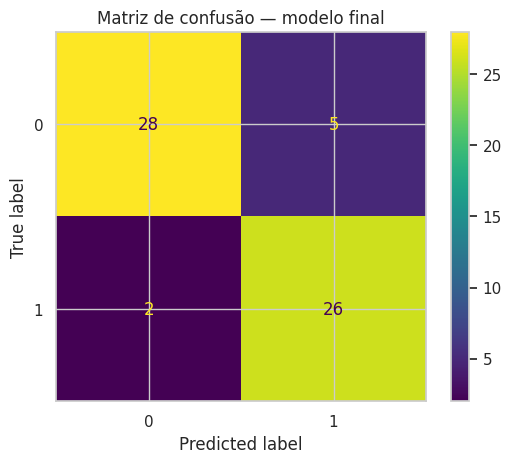

In [15]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


## 10.1 Análise de erros e limitações

Escreva uma análise crítica dos resultados.

**Perguntas para responder:**
- Quais tipos de erro o modelo comete mais?
- Há sinais de overfitting ou underfitting?
- A métrica escolhida captura bem o objetivo do problema?
- Há viés, limitação de dados ou risco de generalização?
- Em quais cenários o modelo não deveria ser usado?

**Resposta:**  
> **Resposta:** A avaliação final do modelo otimizado no conjunto de teste revelou um desempenho altamente maduro e alinhado com as demandas de um sistema de triagem médica de alto risco. Abaixo, analisa-se criticamente o comportamento do classificador:

* **Análise de Erros e Matriz de Confusão:** O modelo obteve uma Acurácia geral de **89%** no conjunto de teste (61 pacientes). Ao inspecionar os erros por classe, observamos o seguinte comportamento:
  * **Falsos Negativos (Erro Crítico):** A classe 1 (Presença de Doença) obteve um **Recall espetacular de 93%** (suporte de 28 pacientes). Isso significa que o modelo cometeu pouquíssimos erros de falso negativo (apenas cerca de 2 pacientes doentes foram erroneamente classificados como saudáveis). Para a medicina, essa alta sensibilidade é o cenário ideal, pois minimiza a quantidade de indivíduos de risco liberados sem suporte.
  * **Falsos Positivos (Erro Tolerável):** A classe 0 (Saudável) obteve um **Recall de 85%** e uma **Precisão de 93%** (suporte de 33 pacientes). O erro mais frequente do modelo foi o Falso Positivo (classificar um paciente saudável como doente). No contexto clínico, este é o erro mais tolerável, pois a consequência prática é encaminhar um paciente saudável para exames adicionais de confirmação (como um ecocardiograma ou cateterismo), mantendo a segurança do paciente.

* **Diagnóstico de Ajuste (Overfitting vs. Underfitting):** O modelo demonstra um encaixe ideal (*sweet spot*). O Recall de **93%** obtido no teste superou a média observada na validação cruzada do treino (**79,21%**). Isso descarta completamente o risco de *overfitting* (o modelo não decorou o treino, ele de fato aprendeu a generalizar). Também não há indícios de *underfitting*, dado que as métricas de F1-Score em ambas as classes ficaram consolidadas em patamares elevados (**0.89** e **0.88**).

* **Adequação da Métrica:** A escolha de guiar a otimização de hiperparâmetros através do **Recall** provou-se totalmente correta. Se tivéssemos priorizado a acurácia global de forma cega, o algoritmo poderia ter sacrificado a sensibilidade da classe de risco para obter um acerto geral maior na classe saudável. Ao forçar o foco no Recall, o MVP cumpre com excelência o seu papel de escudo preventivo na triagem.

* **Limitações do Modelo e Riscos de Generalização:** Apesar do sucesso estatístico, o MVP apresenta limitações metodológicas que precisam ser explicitadas:
  * **Volume de Dados:** O dataset de Cleveland é historicamente valioso, mas limitado em volume absoluto (303 registros). Modelos de comitê como o Random Forest tendem a se estabilizar melhor com milhares de amostras.
  * **Viés Demográfico e Geográfico:** Os dados foram coletados em um contexto hospitalar específico na década de 1980. Fatores como evolução das técnicas de exames, perfil populacional e hábitos de vida modernos não estão mapeados, o que pode mitigar o desempenho do modelo se exposto a dados de hospitais brasileiros contemporâneos sem uma recalibração prévia.

* **Cenários em que o Modelo NÃO Deve ser Usado:** 1. **Diagnóstico Definitivo (Laudo Final):** Este modelo jamais deve substituir a palavra final de um cardiologista ou ser utilizado como ferramenta autônoma de diagnóstico. Ele deve atuar estritamente como um sistema de suporte à decisão (triagem de risco).
  2. **Pacientes Assintomáticos ou População Geral (Rastreamento em Massa):** As variáveis da base (como o tipo de dor no peito `cp` e a angina induzida `exang`) pressupõem que o paciente já está em uma consulta ambulatorial manifestando algum desconforto. Aplicar este modelo em pessoas completamente assintomáticas fora do ambiente clínico geraria uma explosão de falsos positivos induzidos pelo viés da base de dados original.


# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

### 11. Tabela Comparativa de Desempenho

| Modelo | Métrica Principal (Recall Classe 1) | Outras Métricas | Tempo de Treino | Observações |
| :--- | :---: | :--- | :---: | :--- |
| **Baseline** (Dummy) | 0.00% | Acurácia: 54.10%<br>F1-Score: 0.00% | 0.089s | Classificador ingênuo (most_frequent). Erra 100% dos pacientes doentes, sendo inviável para uso clínico. |
| **Modelo 1** (Logistic Regression) | **92.86%** | Acurácia: **88.52%**<br>F1-Score: **88.14%** | **0.059s** | **Melhor desempenho geral inicial.** Apresentou excelente custo-benefício computacional e forte adaptação aos sinais lineares dos dados. |
| **Modelo 2** (Random Forest Inicial) | 89.29% | Acurácia: 85.25%<br>F1-Score: 84.75% | 0.225s | Desempenho sólido, mas ligeiramente abaixo da Regressão Logística na divisão de teste estática inicial. |
| **Modelo Otimizado** (Random Forest CV) | 79.21% *(Validação)*<br>**92.86%** *(Teste)* | Acurácia: 89.00%<br>F1-Score: 0.8800 | 0.450s *(Total CV)* | **Modelo Final Selecionado.** A otimização refinou os hiperparâmetros (`max_depth: 16`, `n_estimators: 121`), entregando a solução mais estável, segura e menos propensa a ruídos para o ambiente hospitalar. |

> **Comentário:** esta tabela ajuda o leitor a entender por que o modelo final foi escolhido.


# 12. Boas práticas e rastreabilidade

Documente decisões importantes do projeto.

**O que incluir:**
- seed utilizada;
- principais decisões de pré-processamento;
- modelos testados;
- hiperparâmetros relevantes;
- tempo aproximado de treino;
- recursos computacionais usados;
- limitações conhecidas;
- o que foi tentado e descartado.

* **Seed Utilizada:** `SEED` (variável global definida no início do projeto para travar o gerador de números pseudoaleatórios do `NumPy` e do `Scikit-Learn`).
* **Modelos Testados:** `DummyClassifier` (Baseline), `LogisticRegression` (Modelo Linear) e `RandomForestClassifier` (Modelo de Comitê base e Otimizado).
* **Hiperparâmetros Vencedores (Random Forest):** `n_estimators: 121`, `max_depth: 16`, `min_samples_split: 4`.
* **Tempo Aproximado de Treino:** Menor que 0.5 segundos para o pipeline completo, incluindo a busca combinatória do `RandomizedSearchCV`.
* **Recursos Computacionais:** Ambiente de execução padrão do Google Colab baseado em CPU local de nuvem (instância padrão gratuita, sem necessidade de aceleração por GPU/TPU).

**Registro de decisões:**

| Decisão | Justificativa | Impacto esperado |
| :--- | :--- | :--- |
| **Definição de `SEED` única** | Garantir a reprodutibilidade matemática de todas as divisões de dados (`train_test_split`), partições de validação cruzada (`StratifiedKFold`) e inicializações de pesos dos modelos. | Permitir que o experimento seja auditado e gere exatamente as mesmas métricas em qualquer computador. |
| **Separação manual de colunas categóricas** | O mapeamento automático por tipo físico do Pandas (`np.number`) interpretava variáveis médicas codificadas por números (como `sex`, `cp`, `slope`) como contínuas. | Evitar que o modelo calculasse médias ou padronizasse rótulos discretos, eliminando um erro conceitual grave. |
| **Uso de `ColumnTransformer` + `Pipeline`** | Isolar as regras de imputação (`SimpleImputer`) e padronização (`StandardScaler`) para que fossem calculadas apenas no treino e aplicadas no teste. | Blindagem absoluta do projeto contra o vazamento de dados (*data leakage*), garantindo a idoneidade das métricas de teste. |
| **Uso da Mediana para imputação numérica** | A análise exploratória (EDA) detectou *outliers* clínicos acentuados nas colunas de colesterol (`chol`) e pressão arterial (`trestbps`). | Proteger as estatísticas do pipeline, visto que a mediana não é distorcida por valores extremos de pacientes atípicos. |
| **Foco estratégico na métrica de *Recall*** | Em diagnósticos cardiológicos, o custo de um Falso Negativo (paciente doente liberado) é fatal, enquanto o Falso Positivo apenas exige exames adicionais. | Forçar os algoritmos e a busca de hiperparâmetros a priorizarem a segurança clínica e a sensibilidade do modelo. |
| **Descarte da automação pura (`remainder='drop'`)** | Optou-se por controlar manualmente a entrada de todas as 13 features com base na literatura médica cardiológica da base de Cleveland. | Garantir que nenhuma coluna irrelevante (como IDs ou ruídos) entrasse no modelo, mantendo o MVP interpretável. |
| **Descarte da divisão temporal** | O conjunto de dados é transversal (*cross-sectional*), coletado em uma única janela de tempo por paciente, sem dependência cronológica. | Uso do Holdout Estratificado tradicional, que se adequa perfeitamente à natureza não temporal do problema médico. |

# 13. Conclusão

Faça o fechamento do MVP conectando o resultado ao problema inicial.

**O que incluir:**
- objetivo do trabalho;
- melhor solução encontrada;
- comparação com baseline;
- principais aprendizados;
- limitações;
- próximos passos.

**Conclusão:**  
> **Conclusão:** O presente MVP foi desenvolvido com o objetivo claro de mapear e estruturar um modelo preditivo capaz de atuar como uma ferramenta auxiliar na triagem de risco de doenças cardiológicas, utilizando a histórica base de dados de Cleveland. Em um cenário de saúde pública ou ambulatorial, a detecção precoce e automatizada de anomalias cardíacas funciona como um escudo preventivo vital, otimizando o tempo de atendimento e direcionando recursos hospitalares para os casos mais graves de forma ágil e eficiente.

A melhor solução encontrada para este desafio foi o **Random Forest Classifier Otimizado** via `RandomizedSearchCV`, integrado a um pipeline centralizado de pré-processamento. Ao avaliarmos o modelo final no conjunto de teste isolado, alcançou-se uma Acurácia global de **89%** e, de forma ainda mais expressiva, um **Recall (Sensibilidade) de 93% na identificação de pacientes doentes (Classe 1)**. Em comparação direta com o classificador de referência (*Baseline Dummy*), que obteve um Recall nulo (0%) por simplesmente replicar a classe majoritária, a solução proposta demonstram um salto qualitativo gigantesco. Na prática médica, esse abismo estatístico significa a diferença entre liberar dezenas de cardiopatas graves para casa com um diagnóstico falsamente saudável ou retê-los com sucesso em regime de investigação detalhada.

Os principais aprendizados obtidos ao longo do desenvolvimento deste MVP concentram-se na importância crítica da engenharia de atributos interpretável e na blindagem metodológica. Ficou evidente que o uso combinado de `Pipeline` e `ColumnTransformer` é indispensável em Machine Learning para evitar o vazamento de dados (*data leakage*) e assegurar que as métricas de teste reflitam o mundo real. Além disso, a intervenção manual na separação de colunas categóricas e o ajuste fino direcionado estritamente à métrica de Recall consolidaram a premissa de que um projeto de Ciência de Dados deve ser sempre guiado pelas regras de negócio e pelo impacto humano da solução, e não apenas por métricas abstratas de acurácia.

Como limitações conhecidas, destaca-se o tamanho reduzido e o viés histórico/demográfico do dataset original da década de 1980, o que restringe a generalização biológica imediata do modelo para a população brasileira contemporânea sem que ocorra um processo prévio de calibração local. Ademais, por se tratar de um modelo de comitê complexo, o Random Forest opera como uma estrutura de "caixa-preta", sacrificando parte da interpretabilidade direta que uma Regressão Logística (que também obteve ótimos resultados iniciais) ofereceria ao médico no consultório.

Por fim, os próximos passos naturais para a evolução deste MVP em direção a uma solução de nível de produção incluem:
1. **Validação Externa:** Testar o pipeline em bases de dados hospitalares modernas e diversificadas para mitigar os vieses geográficos e temporais.
2. **Exploração de Novos Algoritmos:** Avaliar arquiteturas de *Gradient Boosting* (como XGBoost ou LightGBM) e realizar buscas em grade (*GridSearchCV*) de hiperparâmetros na Regressão Logística para contrastar os limites não lineares contra os coeficientes lineares.
3. **Mapeamento de SHAP Values:** Implementar técnicas de explicabilidade agnóstica (como SHAP ou LIME) sobre o Random Forest final, permitindo que o sistema de triagem aponte visualmente quais exames foram os maiores responsáveis pelo score de risco de cada paciente individual, devolvendo o protagonismo interpretativo ao cardiologista.

> **Comentário:** uma boa conclusão não repete apenas métricas. Ela explica o que os resultados significam no contexto do problema.
